# Phase 2 — Elliptic Bitcoin

Compares two axes vs Phase 1 (loaded from CSV):

| New in Phase 2 | Description |
|----------------|-------------|
| AISO(Rand)→AISO(Rand M) | SC: stage-2 M switched to Rand |
| AISO(Smart)→AISO(Rand M) | SC: stage-2 M switched to Rand |
| GraphSAGE (full graph) | GNN paradigm replacement — neighbor sampling |
| GraphSAINT (random walk) | GNN paradigm replacement — subgraph sampling |

All evaluated on Elliptic Bitcoin only, 5 seeds.

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix
import copy, time
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE        = Path(r'C:\Users\kevin\OneDrive\Desktop\AISO')
GAMMA       = 0.5
GNN_SEED    = 42
SEEDS       = [0, 7, 42, 77, 123]
GNN_EPOCHS  = 150
GNN_PATIENCE = 15
GNN_BUDGET  = 3

ELLIPTIC_CFG = dict(
    K_SELECT=20, N_TYPES=12, K_DOM=8, N_DOM_TYPES=4,
    N_ILLICIT=1000, N_LICIT=10000, N_COMBO_TYPES=3,
)

print('Device:', DEVICE)

c:\Users\kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
def load_elliptic(cfg):
    ELLIPTIC_DIR = BASE / 'Elliptic Bitcoin' / 'elliptic_bitcoin_dataset'
    feat_df = pd.read_csv(str(ELLIPTIC_DIR / 'elliptic_txs_features.csv'), header=None)
    cls_df  = pd.read_csv(str(ELLIPTIC_DIR / 'elliptic_txs_classes.csv'))
    edge_df = pd.read_csv(str(ELLIPTIC_DIR / 'elliptic_txs_edgelist.csv'))

    feat_df.columns = ['txId'] + [f'f{i}' for i in range(1, 167)]
    df      = feat_df.merge(cls_df, on='txId')
    labeled = df[df['class'] != 'unknown'].copy().reset_index(drop=True)

    X      = labeled[[f'f{i}' for i in range(1, 167)]].values.astype(float)
    y      = (labeled['class'] == '1').astype(int).values
    ts_all = labeled['f1'].astype(int).values

    txid_to_idx = {txid: i for i, txid in enumerate(labeled['txId'].values)}
    s_arr = edge_df.iloc[:, 0].values
    d_arr = edge_df.iloc[:, 1].values
    s_map = np.array([txid_to_idx.get(t, -1) for t in s_arr])
    d_map = np.array([txid_to_idx.get(t, -1) for t in d_arr])
    ok    = (s_map >= 0) & (d_map >= 0) & (s_map != d_map)
    src, dst = s_map[ok], d_map[ok]
    src_bi = np.concatenate([src, dst])
    dst_bi = np.concatenate([dst, src])
    edge_index = torch.tensor(np.stack([src_bi, dst_bi]), dtype=torch.long)
    ei_np = edge_index.numpy()

    N          = len(y)
    train_mask = ts_all <= 34
    test_mask  = ts_all > 34

    X_scaled          = StandardScaler().fit_transform(X)
    train_illicit_idx = np.where(train_mask & (y == 1))[0]
    train_licit_idx   = np.where(train_mask & (y == 0))[0]

    n_illicit = min(cfg['N_ILLICIT'], len(train_illicit_idx))
    n_licit   = min(cfg['N_LICIT'],   len(train_licit_idx))
    sel_n     = np.random.RandomState(GNN_SEED).choice(train_licit_idx, n_licit, replace=False)

    illicit_ratio = (y == 1).sum() / N
    print(f'  Elliptic: N={N}  illicit={100*illicit_ratio:.1f}%  D={X.shape[1]}  '
          f'train_illicit={len(train_illicit_idx)}')

    return dict(
        X_raw=X, X_scaled=X_scaled, y=y,
        edge_index=edge_index, ei_np=ei_np,
        train_mask=train_mask, test_mask=test_mask,
        train_illicit_idx=train_illicit_idx, train_licit_idx=train_licit_idx,
        sel_n=sel_n,
        X_illicit_pool=X_scaled[train_illicit_idx],
        X_tr_all=X_scaled[train_mask],
        y_tr_all=y[train_mask],
        N_NODES=N, D=X.shape[1],
        N_ILLICIT=n_illicit, N_LICIT=n_licit,
    )

print('Loading Elliptic...')
elliptic_data = load_elliptic(ELLIPTIC_CFG)

# Phase 1 results
p1_df = pd.read_csv(BASE / 'final_showdown_results.csv')
p1_ell = p1_df[p1_df['dataset'] == 'Elliptic'].copy()
p1_summary = (
    p1_ell.groupby('method')['gnn_pr_auc']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'PR-AUC', 'std': 'std'})
    .sort_values('PR-AUC', ascending=False)
)
print('\nPhase 1 Elliptic results loaded:')
print(p1_summary.to_string(float_format='%.4f'))

Loading Elliptic...
  Elliptic: N=46564  illicit=9.8%  D=166  train_illicit=3462

Phase 1 Elliptic results loaded:
                    PR-AUC    std
method                           
AISO(Smart)->AISO   0.6644 0.0223
mRMR->AISO(Rand)    0.6348 0.0552
mRMR->SGD           0.6348 0.0062
MI->AISO(Smart)     0.6312 0.0168
Greedy-Raw          0.6245 0.0242
MI->SGD             0.6138 0.0163
mRMR->AISO(Smart)   0.6060 0.0832
MI->AISO(Rand)      0.6018 0.0665
AISO-node(Rand M)   0.6004 0.0906
AISO(Smart)->SGD    0.5956 0.0509
AISO(Rand)->AISO    0.5872 0.0371
AISO(Rand)->SGD     0.5676 0.0756
Random              0.5530 0.0714
K-Means             0.5126 0.1332
Degree              0.4933 0.0000
AISO-node(Smart M)  0.3972 0.0643
Greedy-Dom          0.3836 0.0651
PageRank            0.3428 0.0000


In [3]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_ch, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
        self.drop  = dropout

    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.lin(x)


def evaluate_graphsage(data, gnn_seed=GNN_SEED):
    """Full-graph GraphSAGE — SAGEConv on full edge_index, no torch-sparse needed."""
    X_scaled   = data['X_scaled']
    y_all      = data['y']
    train_mask = data['train_mask']
    test_mask  = data['test_mask']

    x_t = torch.from_numpy(X_scaled).float().to(DEVICE)
    y_t = torch.from_numpy(y_all).long().to(DEVICE)
    ei  = data['edge_index'].to(DEVICE)
    tr  = torch.from_numpy(train_mask).to(DEVICE)

    y_tr = y_all[train_mask]
    n0 = int((y_tr == 0).sum()); n1 = int((y_tr == 1).sum())
    cw = torch.tensor([1.0, n0 / max(n1, 1)], dtype=torch.float).to(DEVICE)

    torch.manual_seed(gnn_seed)
    model = GraphSAGE(X_scaled.shape[1]).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    best_loss, best_state, patience = float('inf'), None, 0
    for epoch in range(GNN_EPOCHS):
        model.train(); opt.zero_grad()
        out  = model(x_t, ei)
        loss = F.cross_entropy(out[tr], y_t[tr], weight=cw)
        loss.backward(); opt.step()
        if loss.item() < best_loss:
            best_loss = loss.item(); best_state = copy.deepcopy(model.state_dict()); patience = 0
        else:
            patience += 1
        if patience >= GNN_PATIENCE: break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        prob = F.softmax(model(x_t, ei), dim=1)[:, 1].cpu().numpy()

    y_te    = y_all[test_mask]
    prob_te = prob[test_mask]
    return {
        'PR-AUC': average_precision_score(y_te, prob_te),
        'F1':     f1_score(y_te, (prob_te >= 0.5).astype(int), zero_division=0),
        'AUC':    roc_auc_score(y_te, prob_te),
    }


print('GraphSAGE eval ready')

GraphSAGE eval ready


In [4]:
def evaluate_graphsaint(data, gnn_seed=GNN_SEED, batch_size=2000):
    """GraphSAINT-style stochastic training — random node subset per epoch,
    full-graph message passing. No torch-sparse needed."""
    X_scaled   = data['X_scaled']
    y_all      = data['y']
    train_mask = data['train_mask']
    test_mask  = data['test_mask']

    x_t = torch.from_numpy(X_scaled).float().to(DEVICE)
    y_t = torch.from_numpy(y_all).long().to(DEVICE)
    ei  = data['edge_index'].to(DEVICE)
    tr_idx = np.where(train_mask)[0]

    y_tr = y_all[train_mask]
    n0 = int((y_tr == 0).sum()); n1 = int((y_tr == 1).sum())
    cw = torch.tensor([1.0, n0 / max(n1, 1)], dtype=torch.float).to(DEVICE)

    torch.manual_seed(gnn_seed)
    rng   = np.random.RandomState(gnn_seed)
    model = GraphSAGE(X_scaled.shape[1]).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    N = data['N_NODES']
    best_loss, best_state, patience = float('inf'), None, 0
    for epoch in range(GNN_EPOCHS):
        model.train(); opt.zero_grad()
        seeds = rng.choice(tr_idx, min(batch_size, len(tr_idx)), replace=False)
        mask  = torch.zeros(N, dtype=torch.bool, device=DEVICE)
        mask[seeds] = True
        out  = model(x_t, ei)
        loss = F.cross_entropy(out[mask], y_t[mask], weight=cw)
        loss.backward(); opt.step()
        if loss.item() < best_loss:
            best_loss = loss.item(); best_state = copy.deepcopy(model.state_dict()); patience = 0
        else:
            patience += 1
        if patience >= GNN_PATIENCE: break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        prob = F.softmax(model(x_t, ei), dim=1)[:, 1].cpu().numpy()

    y_te    = y_all[test_mask]
    prob_te = prob[test_mask]
    return {
        'PR-AUC': average_precision_score(y_te, prob_te),
        'F1':     f1_score(y_te, (prob_te >= 0.5).astype(int), zero_division=0),
        'AUC':    roc_auc_score(y_te, prob_te),
    }


print('GraphSAINT eval ready')

GraphSAINT eval ready


In [5]:
# ── reuse infra from final_showdown ──────────────────────────
from scipy.sparse import diags as sp_diags

def build_feat_M(X_tr, y_tr, N_TYPES, gamma=GAMMA):
    D = X_tr.shape[1]
    C_abs = np.abs(np.corrcoef(X_tr.T)); np.fill_diagonal(C_abs, 0.0)
    dist  = np.clip(1.0 - C_abs, 0.0, None); np.fill_diagonal(dist, 0.0)
    cl    = AgglomerativeClustering(n_clusters=N_TYPES,
                                     metric='precomputed',
                                     linkage='average').fit_predict(dist)
    MI      = mutual_info_classif(X_tr, y_tr, random_state=42)
    mean_MI = np.array([MI[cl==k].mean() if (cl==k).any() else 0.0 for k in range(N_TYPES)])
    MI_norm = (mean_MI - mean_MI.min()) / (mean_MI.max() - mean_MI.min() + 1e-8)

    def _M(mode):
        M = np.zeros((N_TYPES, N_TYPES))
        for i in range(N_TYPES):
            for j in range(N_TYPES):
                if i == j:
                    M[i][j] = -1.0
                else:
                    fi = np.where(cl==i)[0]; fj = np.where(cl==j)[0]
                    cp = -np.mean(C_abs[np.ix_(fi, fj)])
                    M[i][j] = cp + (gamma * (MI_norm[j] - MI_norm[i]) if mode == 'smart' else 0)
        return M

    return _M('smart'), _M('corr'), cl, MI


def mrmr_selection(X_tr, y_tr, X_pool, K, n_illicit, seed):
    mi    = mutual_info_classif(X_tr, y_tr, random_state=seed)
    Cm    = np.abs(np.corrcoef(X_tr.T)); np.fill_diagonal(Cm, 0.0)
    sel   = [int(np.argmax(mi))]
    rem   = list(range(X_tr.shape[1])); rem.remove(sel[0])
    while len(sel) < K:
        sc   = [mi[f] - float(np.mean(Cm[f, sel])) for f in rem]
        best = rem[int(np.argmax(sc))]
        sel.append(best); rem.remove(best)
    return np.array(sel)


class AISOwrapperGNN:
    def __init__(self, n_agents=20, n_iter=60, beta=0.15,
                 subsample_ratio=0.15, val_ratio=0.2,
                 T_start=1.0, T_end=0.05, gnn_budget=GNN_BUDGET):
        self.n_agents = n_agents; self.n_iter = n_iter; self.beta = beta
        self.subsample_ratio = subsample_ratio; self.val_ratio = val_ratio
        self.T_start = T_start; self.T_end = T_end
        self.gnn_budget = gnn_budget

    def select(self, X_tr, y_tr, X_pool, cluster_labels, K_select, n_illicit, M, seed=42):
        rng = np.random.RandomState(seed)
        N, D = X_tr.shape; K = M.shape[0]; nb = min(3, self.n_agents - 1)
        n_pool = len(X_pool)

        val_n   = int(self.val_ratio * N)
        val_idx = rng.choice(N, val_n, replace=False)
        tr_mask = np.ones(N, bool); tr_mask[val_idx] = False
        X_val, y_val = X_tr[val_idx], y_tr[val_idx]
        X_t,   y_t   = X_tr[tr_mask], y_tr[tr_mask]
        sub_n = max(50, int(self.subsample_ratio * len(X_t)))

        cache = {}; n_calls = [0]

        def get_mask(Wi, t, explore=True):
            if explore:
                ratio  = t / max(1, self.n_iter - 1)
                T      = self.T_start * ((self.T_end / self.T_start) ** ratio)
                logits = Wi[cluster_labels] / T; logits -= logits.max()
                probs  = np.exp(logits); probs /= probs.sum()
                return tuple(rng.choice(D, K_select, replace=False, p=probs))
            else:
                return tuple(np.argsort(Wi[cluster_labels])[-K_select:])

        def get_score(mask_key, X_sub, y_sub):
            n_calls[0] += 1
            if mask_key not in cache:
                feat = list(mask_key)
                sgd  = SGDClassifier(loss='log_loss', max_iter=5, tol=None,
                                      class_weight='balanced', random_state=seed)
                try:
                    sgd.fit(X_sub[:, feat], y_sub)
                    proxy_auc = roc_auc_score(y_val, sgd.predict_proba(X_val[:, feat])[:, 1])
                    illicit_p = sgd.predict_proba(X_pool[:, feat])[:, 1]
                except Exception:
                    proxy_auc = 0.5; illicit_p = rng.rand(n_pool)
                cache[mask_key] = {'proxy_auc': proxy_auc, 'illicit_scores': illicit_p}
            return cache[mask_key]['proxy_auc']

        def top_n(mask_key):
            return np.argsort(cache[mask_key]['illicit_scores'])[-n_illicit:]

        W = rng.dirichlet(np.ones(K), self.n_agents)
        scores = np.zeros(self.n_agents)
        for i in range(self.n_agents):
            sub = rng.choice(len(X_t), sub_n, replace=False)
            mk  = get_mask(W[i], 0)
            scores[i] = get_score(mk, X_t[sub], y_t[sub])

        for t in range(self.n_iter):
            Cm = W @ M @ W.T; np.fill_diagonal(Cm, 0.0)
            sub = rng.choice(len(X_t), sub_n, replace=False)
            X_sub, y_sub = X_t[sub], y_t[sub]
            for i in range(self.n_agents):
                att   = np.argsort(Cm[i])[-nb:]
                att_s = np.array([get_score(get_mask(W[j], t), X_sub, y_sub) for j in att])
                max_s = att_s.max() + 1e-8
                bj    = att[np.argmax(Cm[i, att] * att_s / max_s)]
                W_new = (1 - self.beta) * W[i] + self.beta * W[bj]
                W[i]  = W_new / W_new.sum()
                scores[i] = get_score(get_mask(W[i], t), X_sub, y_sub)

        final_lr = LogisticRegression(solver='liblinear', C=1.0, max_iter=500,
                                       class_weight='balanced', random_state=seed)
        fseen, final_scores = {}, []
        for i in range(self.n_agents):
            mk = get_mask(W[i], self.n_iter, explore=False); feat = list(mk)
            if mk not in fseen:
                try:
                    final_lr.fit(X_t[:, feat], y_t)
                    fseen[mk] = roc_auc_score(y_val, final_lr.predict_proba(X_val[:, feat])[:, 1])
                except Exception:
                    fseen[mk] = 0.5
                if mk not in cache:
                    get_score(mk, X_t, y_t)
            final_scores.append(fseen[mk])

        seen_keys, fidelity_cands = set(), []
        for ai in np.argsort(final_scores)[::-1]:
            mk = get_mask(W[ai], self.n_iter, explore=False)
            if mk not in seen_keys and mk in cache:
                seen_keys.add(mk)
                fidelity_cands.append({'feat_mask': np.array(sorted(mk)),
                                        'top_n_local': top_n(mk),
                                        'proxy_auc': cache[mk]['proxy_auc']})
            if len(fidelity_cands) >= self.gnn_budget: break

        best_mk   = get_mask(W[np.argmax(final_scores)], self.n_iter, explore=False)
        best_feat = np.array(sorted(best_mk))
        sgd_fin   = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-4,
                                   class_weight='balanced', random_state=seed)
        try:
            sgd_fin.fit(X_t[:, list(best_mk)], y_t)
            top_n_best = np.argsort(sgd_fin.predict_proba(X_pool[:, list(best_mk)])[:, 1])[-n_illicit:]
        except Exception:
            top_n_best = top_n(best_mk)

        return best_feat, top_n_best, {}, fidelity_cands


def run_combo_aiso_node(feat_indices, X_tr, y_tr, X_pool, N_ILLICIT,
                        N_COMBO_TYPES, seed, M_mode_2='random'):
    X_tr_2   = X_tr[:, feat_indices]
    X_pool_2 = X_pool[:, feat_indices]
    K2       = len(feat_indices)
    nc = min(N_COMBO_TYPES, K2)
    M_smart_2, _, cl_2, _ = build_feat_M(X_tr_2, y_tr, nc)
    M_use_2 = (np.random.RandomState(seed).uniform(-0.5, 2.0, (nc, nc))
               if M_mode_2 == 'random' else M_smart_2)
    K_select_2 = max(2, K2 // 2)
    wrapper_2  = AISOwrapperGNN(n_agents=20, n_iter=60, beta=0.15,
                                T_start=1.0, T_end=0.05, gnn_budget=GNN_BUDGET)
    _, top_n_best, _, fid_cands = wrapper_2.select(
        X_tr_2, y_tr, X_pool_2, cl_2, K_select_2, N_ILLICIT, M_use_2, seed=seed)
    return fid_cands[0]['top_n_local'] if fid_cands else top_n_best


print('AISO infra ready')

AISO infra ready


In [6]:
import torch.nn as nn
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
        self.drop  = dropout

    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.lin(x)


def make_evaluate_gnn(data, gnn_seed=GNN_SEED):
    X_scaled          = data['X_scaled']
    y_all             = data['y']
    train_illicit_idx = data['train_illicit_idx']
    sel_n             = data['sel_n']
    ei_np             = data['ei_np']
    N_NODES           = data['N_NODES']
    test_mask         = data['test_mask']
    _LU               = np.full(N_NODES, -1, dtype=np.int32)

    def evaluate_gnn(top_n_illicit_local, label=''):
        uniq            = np.unique(top_n_illicit_local)
        sel_anom_global = train_illicit_idx[uniq]
        test_global     = np.where(test_mask)[0]
        sub_nodes       = np.unique(np.concatenate([sel_n, sel_anom_global, test_global]))
        n_sub           = len(sub_nodes)

        _LU[:] = -1
        _LU[sub_nodes] = np.arange(n_sub)
        sl = _LU[ei_np[0]]; dl = _LU[ei_np[1]]
        ok = (sl >= 0) & (dl >= 0)
        sub_ei = torch.tensor([sl[ok], dl[ok]], dtype=torch.long).to(DEVICE)
        sub_X  = torch.from_numpy(X_scaled[sub_nodes]).float().to(DEVICE)
        sub_y  = torch.from_numpy(y_all[sub_nodes]).long().to(DEVICE)

        train_set = set(np.concatenate([sel_n, sel_anom_global]).tolist())
        test_set  = set(test_global.tolist())
        tr_gnn = torch.tensor([g in train_set for g in sub_nodes], dtype=torch.bool).to(DEVICE)
        te_gnn = torch.tensor([g in test_set  for g in sub_nodes], dtype=torch.bool).to(DEVICE)

        y_tr_sub = y_all[sub_nodes][tr_gnn.cpu().numpy()]
        n0 = int((y_tr_sub == 0).sum()); n1 = int((y_tr_sub == 1).sum())
        cw = torch.tensor([1.0, n0 / max(n1, 1)], dtype=torch.float).to(DEVICE)

        torch.manual_seed(gnn_seed)
        model = GCN(X_scaled.shape[1]).to(DEVICE)
        opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

        best_loss, best_state, patience = float('inf'), None, 0
        for _ in range(GNN_EPOCHS):
            model.train(); opt.zero_grad()
            loss = F.cross_entropy(model(sub_X, sub_ei)[tr_gnn], sub_y[tr_gnn], weight=cw)
            loss.backward(); opt.step()
            if loss.item() < best_loss:
                best_loss = loss.item(); best_state = copy.deepcopy(model.state_dict()); patience = 0
            else:
                patience += 1
            if patience >= GNN_PATIENCE: break

        model.load_state_dict(best_state); model.eval()
        with torch.no_grad():
            prob = F.softmax(model(sub_X, sub_ei), dim=1)[:, 1].cpu().numpy()

        te_cpu  = te_gnn.cpu().numpy()
        y_te    = y_all[sub_nodes][te_cpu]
        prob_te = prob[te_cpu]
        res = {
            'PR-AUC': average_precision_score(y_te, prob_te),
            'F1':     f1_score(y_te, (prob_te >= 0.5).astype(int), zero_division=0),
            'AUC':    roc_auc_score(y_te, prob_te),
        }
        if label:
            print('  %-44s PR-AUC=%.4f  F1=%.4f' % (label, res['PR-AUC'], res['F1']))
        return res

    return evaluate_gnn


print('GCN eval ready')

GCN eval ready


In [7]:
data         = elliptic_data
cfg          = ELLIPTIC_CFG
evaluate_gnn = make_evaluate_gnn(data)

# ── 이미 실행된 AISO(x)->AISO(Rand M) 결과 하드코딩 ──────
p2_results = {
    'AISO(Rand)->AISO(Rand M)': [
        {'seed': 0,   'PR-AUC': 0.4612, 'F1': 0.2979, 'AUC': 0.0},
        {'seed': 7,   'PR-AUC': 0.6397, 'F1': 0.4362, 'AUC': 0.0},
        {'seed': 42,  'PR-AUC': 0.5828, 'F1': 0.5702, 'AUC': 0.0},
        {'seed': 77,  'PR-AUC': 0.4112, 'F1': 0.4033, 'AUC': 0.0},
        {'seed': 123, 'PR-AUC': 0.6563, 'F1': 0.6361, 'AUC': 0.0},
    ],
    'AISO(Smart)->AISO(Rand M)': [
        {'seed': 0,   'PR-AUC': 0.6861, 'F1': 0.6000, 'AUC': 0.0},
        {'seed': 7,   'PR-AUC': 0.6750, 'F1': 0.6474, 'AUC': 0.0},
        {'seed': 42,  'PR-AUC': 0.6142, 'F1': 0.4918, 'AUC': 0.0},
        {'seed': 77,  'PR-AUC': 0.6578, 'F1': 0.6255, 'AUC': 0.0},
        {'seed': 123, 'PR-AUC': 0.6221, 'F1': 0.6023, 'AUC': 0.0},
    ],
}

for m, rl in p2_results.items():
    prs = [r['PR-AUC'] for r in rl]
    print('  %-32s mean=%.4f  std=%.4f' % (m, np.mean(prs), np.std(prs)))

  AISO(Rand)->AISO(Rand M)         mean=0.5502  std=0.0975
  AISO(Smart)->AISO(Rand M)        mean=0.6510  std=0.0284


In [8]:
# ── GNN baselines (run separately after AISO variants) ────
print('[GraphSAGE — full-graph SAGEConv]')
rl = []
for seed in SEEDS:
    print('  seed=%d ...' % seed, end='', flush=True)
    t0 = time.time()
    r = evaluate_graphsage(data, gnn_seed=seed)
    print(' %.0fs  PR-AUC=%.4f' % (time.time()-t0, r['PR-AUC']))
    r['seed'] = seed; rl.append(r)
p2_results['GraphSAGE'] = rl

print('\n[GraphSAINT — stochastic node sampling]')
rl = []
for seed in SEEDS:
    print('  seed=%d ...' % seed, end='', flush=True)
    t0 = time.time()
    r = evaluate_graphsaint(data, gnn_seed=seed)
    print(' %.0fs  PR-AUC=%.4f' % (time.time()-t0, r['PR-AUC']))
    r['seed'] = seed; rl.append(r)
p2_results['GraphSAINT'] = rl

print('\n>>> Phase 2 done')

[GraphSAGE — full-graph SAGEConv]
  seed=0 ... 100s  PR-AUC=0.7317
  seed=7 ... 80s  PR-AUC=0.7156
  seed=42 ... 82s  PR-AUC=0.6919
  seed=77 ... 76s  PR-AUC=0.6943
  seed=123 ... 60s  PR-AUC=0.7307

[GraphSAINT — stochastic node sampling]
  seed=0 ... 49s  PR-AUC=0.6531
  seed=7 ... 40s  PR-AUC=0.6807
  seed=42 ... 33s  PR-AUC=0.6977
  seed=77 ... 31s  PR-AUC=0.4368
  seed=123 ... 44s  PR-AUC=0.6683

>>> Phase 2 done



  Elliptic — Phase 1 + Phase 2 Combined
  Ph   Method                           PR-AUC     std
  ------------------------------------------------------
  P2   GraphSAGE                        0.7128  0.0171
  P1   AISO(Smart)->AISO                0.6644  0.0223
  P2   AISO(Smart)->AISO(Rand M)        0.6510  0.0284
  P1   mRMR->AISO(Rand)                 0.6348  0.0552
  P1   mRMR->SGD                        0.6348  0.0062
  P1   MI->AISO(Smart)                  0.6312  0.0168
  P2   GraphSAINT                       0.6273  0.0964
  P1   Greedy-Raw                       0.6245  0.0242
  P1   MI->SGD                          0.6138  0.0163
  P1   mRMR->AISO(Smart)                0.6060  0.0832
  P1   MI->AISO(Rand)                   0.6018  0.0665
  P1   AISO-node(Rand M)                0.6004  0.0906
  P1   AISO(Smart)->SGD                 0.5956  0.0509
  P1   AISO(Rand)->AISO                 0.5872  0.0371
  P1   AISO(Rand)->SGD                  0.5676  0.0756
  P1   Random         

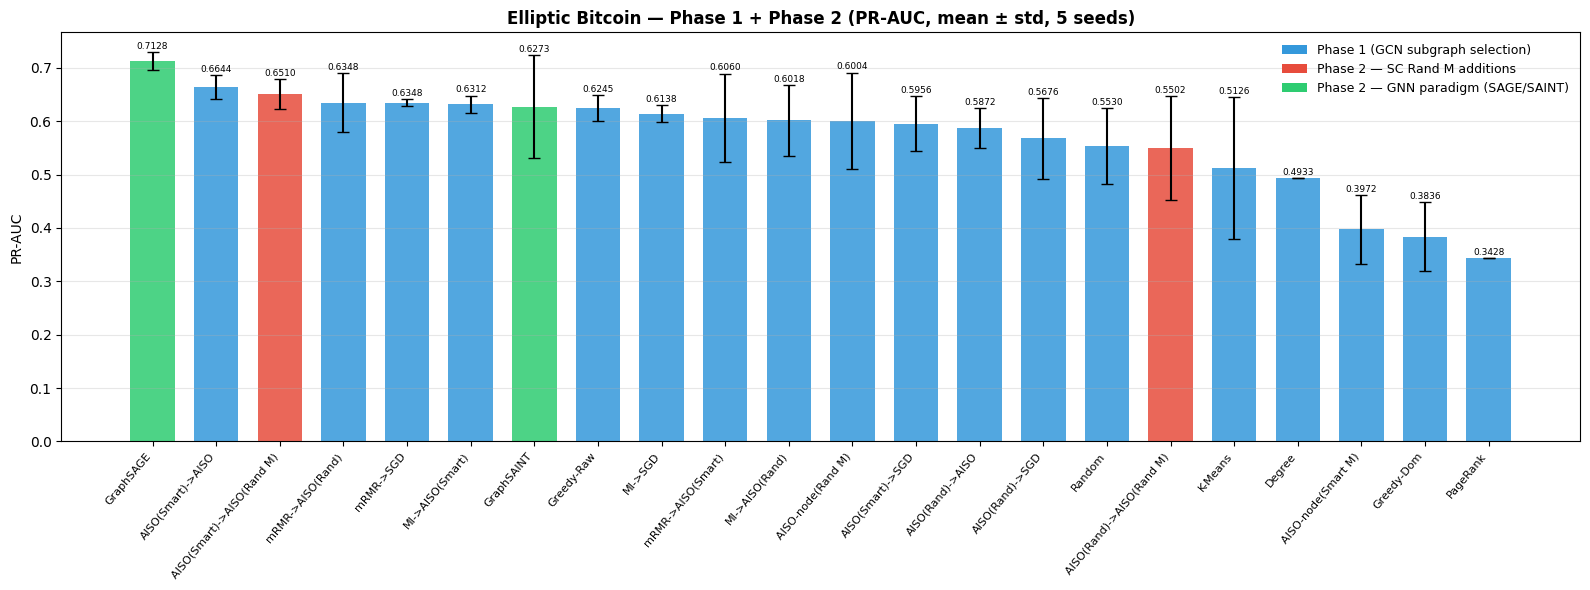

Saved: phase2_elliptic.png


In [9]:
# ── Unified table: Phase 1 + Phase 2 ─────────────────────
p2_summary = {}
for m, rl in p2_results.items():
    prs = [r['PR-AUC'] for r in rl]
    p2_summary[m] = dict(mean=np.mean(prs), std=np.std(prs), phase='P2')

# Merge with Phase 1
rows = []
for m, row in p1_summary.iterrows():
    rows.append({'Method': m, 'PR-AUC': row['PR-AUC'], 'std': row['std'], 'Phase': 'P1'})
for m, d in p2_summary.items():
    rows.append({'Method': m, 'PR-AUC': d['mean'], 'std': d['std'], 'Phase': 'P2'})

combined = pd.DataFrame(rows).sort_values('PR-AUC', ascending=False).reset_index(drop=True)

print('\n' + '='*62)
print('  Elliptic — Phase 1 + Phase 2 Combined')
print('='*62)
print('  %-4s %-30s %8s %7s' % ('Ph', 'Method', 'PR-AUC', 'std'))
print('  ' + '-'*54)
for _, row in combined.iterrows():
    print('  %-4s %-30s %8.4f %7.4f' % (row['Phase'], row['Method'], row['PR-AUC'], row['std']))

# Save
combined.to_csv(BASE / 'phase2_elliptic_results.csv', index=False)
print('\nSaved: phase2_elliptic_results.csv')

# ── Visualization ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
P1_COLOR  = '#3498db'
P2_SC_COLOR = '#e74c3c'
P2_GNN_COLOR = '#2ecc71'

colors = []
for _, row in combined.iterrows():
    if row['Phase'] == 'P1':
        colors.append(P1_COLOR)
    elif 'AISO' in row['Method']:
        colors.append(P2_SC_COLOR)
    else:
        colors.append(P2_GNN_COLOR)

x = np.arange(len(combined))
ax.bar(x, combined['PR-AUC'], yerr=combined['std'], capsize=4,
       color=colors, alpha=0.85, width=0.7)
ax.set_xticks(x)
ax.set_xticklabels(combined['Method'], rotation=50, ha='right', fontsize=8)
ax.set_ylabel('PR-AUC')
ax.set_title('Elliptic Bitcoin — Phase 1 + Phase 2 (PR-AUC, mean ± std, 5 seeds)',
             fontweight='bold')
ax.grid(alpha=0.3, axis='y')
for xi, (mv, sv) in enumerate(zip(combined['PR-AUC'], combined['std'])):
    ax.text(xi, mv + sv + 0.002, '%.4f' % mv, ha='center', va='bottom', fontsize=6.5)

legend_elements = [
    Patch(facecolor=P1_COLOR,    label='Phase 1 (GCN subgraph selection)'),
    Patch(facecolor=P2_SC_COLOR, label='Phase 2 — SC Rand M additions'),
    Patch(facecolor=P2_GNN_COLOR,label='Phase 2 — GNN paradigm (SAGE/SAINT)'),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(BASE / 'phase2_elliptic.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: phase2_elliptic.png')